In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score, roc_auc_score, roc_curve

In [153]:
pd.set_option('display.max_columns', None)

In [154]:
df = pd.read_csv("train.csv")
df.shape

(594194, 21)

In [155]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [157]:
df.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [158]:
object_cols = df.select_dtypes(include='object').columns
object_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [159]:
num_cols = df.select_dtypes(exclude='object').columns
num_cols

Index(['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [160]:
categorical_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',\
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',\
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',\
       'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
target_column = ["Churn"]

### lets check target column distribution

In [161]:
churn_dist = df[target_column].value_counts().to_frame()
churn_dist["percentage"] = (churn_dist["count"]/ df.shape[0]*100).round(2)
churn_dist

,count,percentage
Churn,,
No,460377,77.48
Yes,133817,22.52


In [162]:
print(f"Churn Ration:\nChurn: No Churn = {churn_dist["percentage"].iloc[1]/churn_dist["percentage"].iloc[1]}: {(churn_dist["percentage"].iloc[0]/ churn_dist["percentage"].iloc[1]).round(2)}")

Churn Ration:
Churn: No Churn = 1.0: 3.44


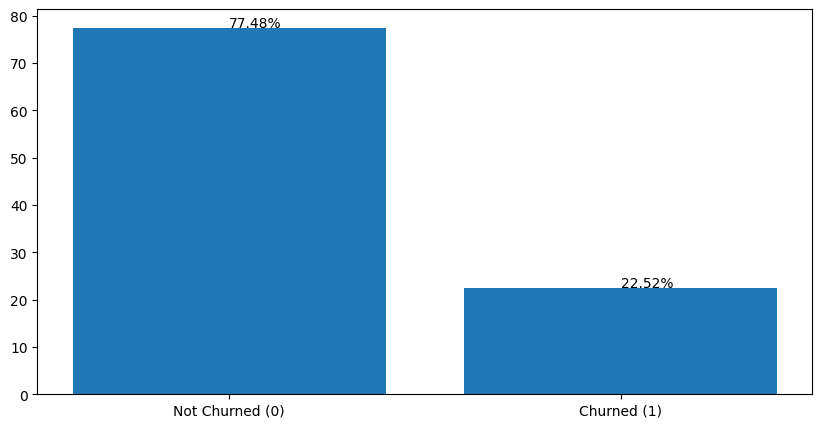

In [163]:
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(['Not Churned (0)', 'Churned (1)'], churn_dist["percentage"])
for i, col in enumerate(churn_dist["percentage"]):
    ax.text(i, col+0.05, f"{col}%")



## Target distribution is imbalance, churn to no churn ratio is 1:3.44. Need to consider this during training the model

# Numerical column analysis - Univariate and Bivariant 

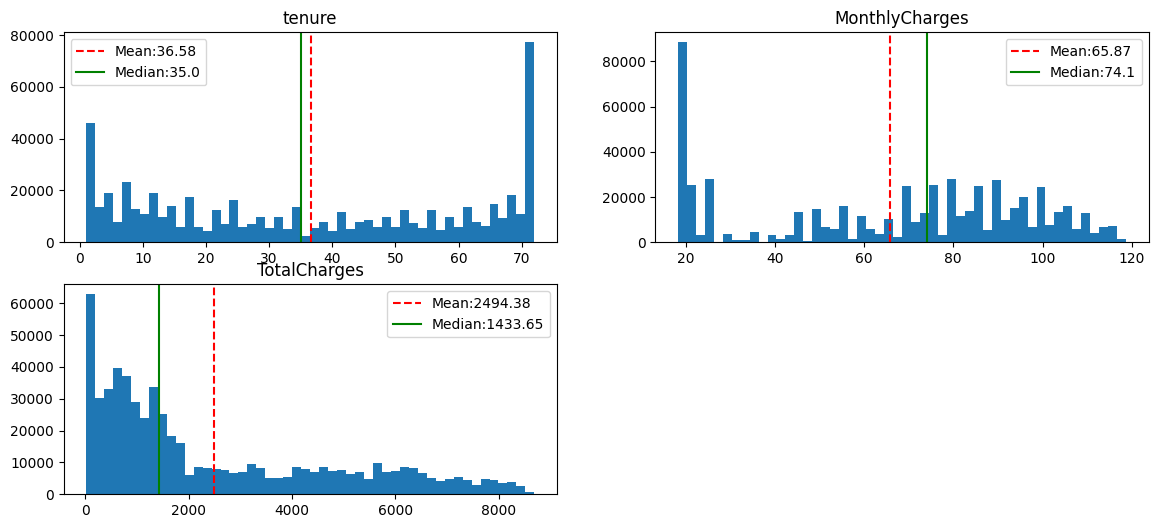

In [164]:
fig, axes = plt.subplots(2,2, figsize = (14,6))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    axes[i].hist(df[col], bins = 50)

    mean = (df[col].mean()).round(2)
    median = (df[col].median()).round(2)

    axes[i].axvline(mean, color = 'red', linestyle="--", label=f"Mean:{mean}")
    axes[i].axvline(median, color='green', linestyle = "-", label = f"Median:{median}")

    axes[i].set_title(col)
    axes[i].legend()

for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(False)


#### Check for outliers

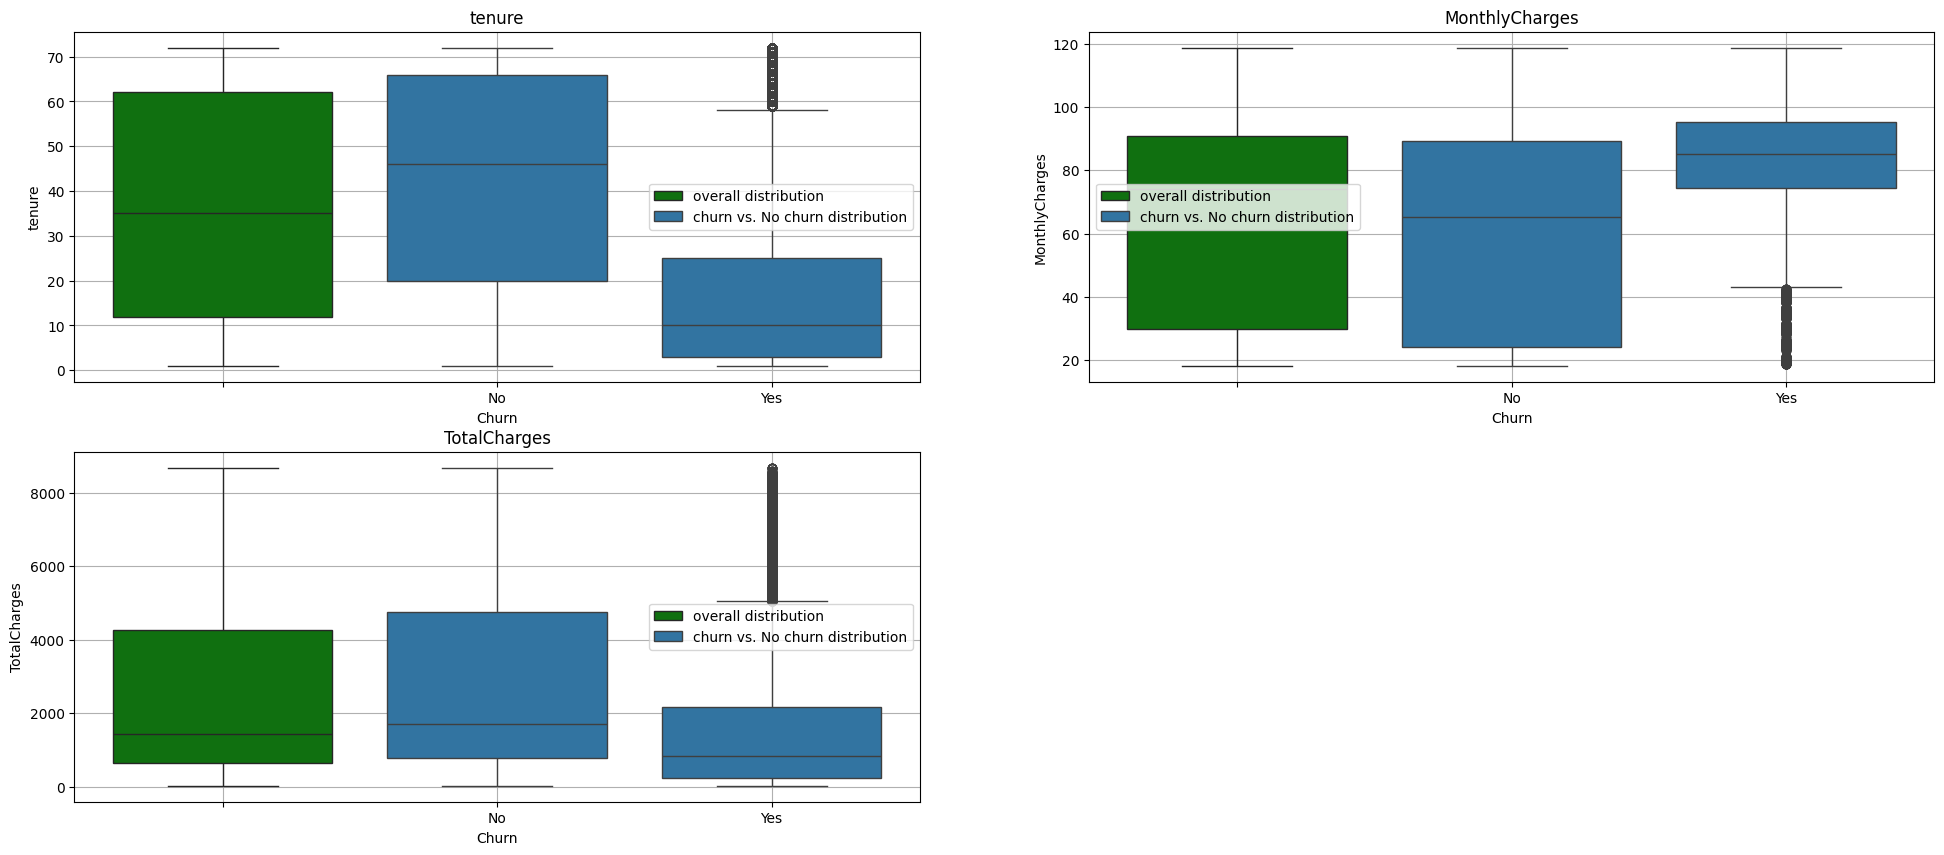

In [165]:
fig, axes = plt.subplots(2,2, figsize = (24,10))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.boxplot(df[col], ax=axes[i], color="green", label="overall distribution")
    sns.boxplot(data=df, x="Churn", y=col, ax=axes[i], label = "churn vs. No churn distribution")
    
    axes[i].set_title(col)
    axes[i].grid()
    axes[i].plot()
    axes[i].legend()

for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(False)

#sns.boxplot(df[col])

In [166]:
churned = df[df["Churn"] == 'Yes']
not_churned = df[df["Churn"] == 'No']

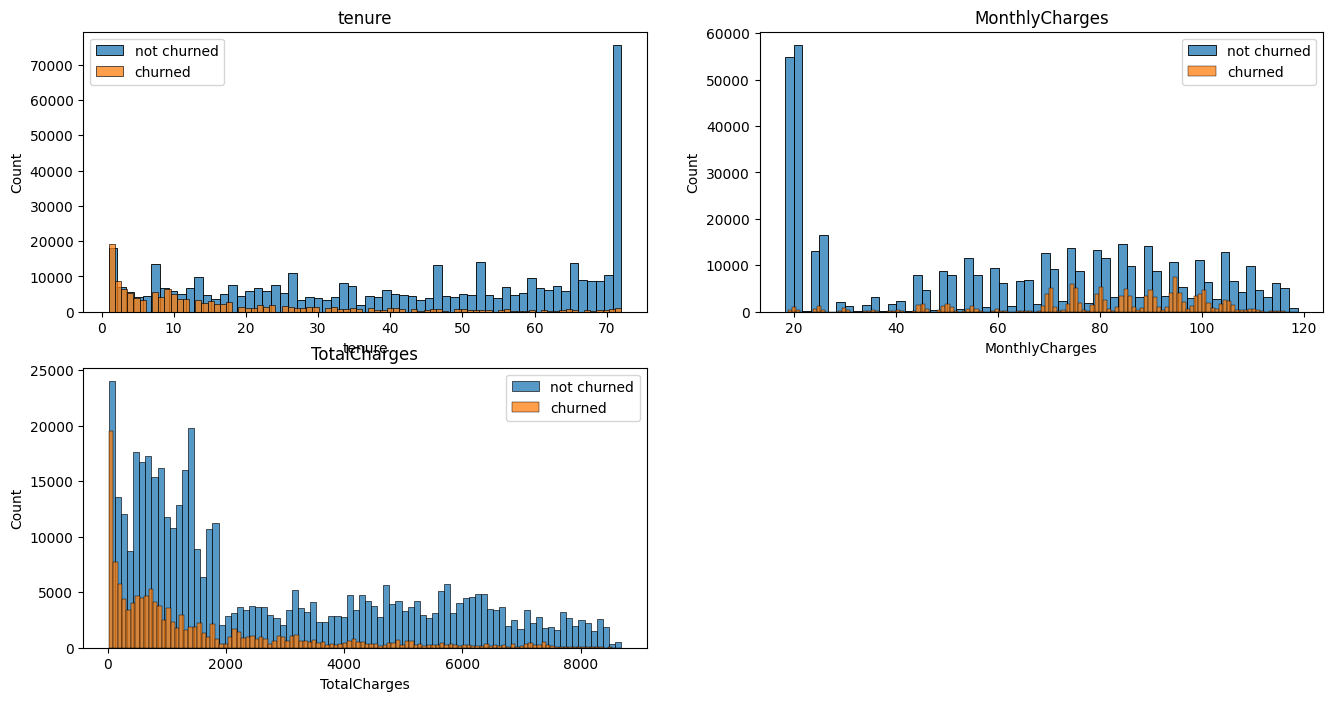

In [167]:
fig, axes = plt.subplots(2,2,figsize=(16,8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(not_churned[col], ax= axes[i], label = "not churned")
    sns.histplot(churned[col], ax=axes[i], label = "churned")

    axes[i].set_title(col)
    axes[i].legend()

for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(None)

<Figure size 1600x1200 with 0 Axes>

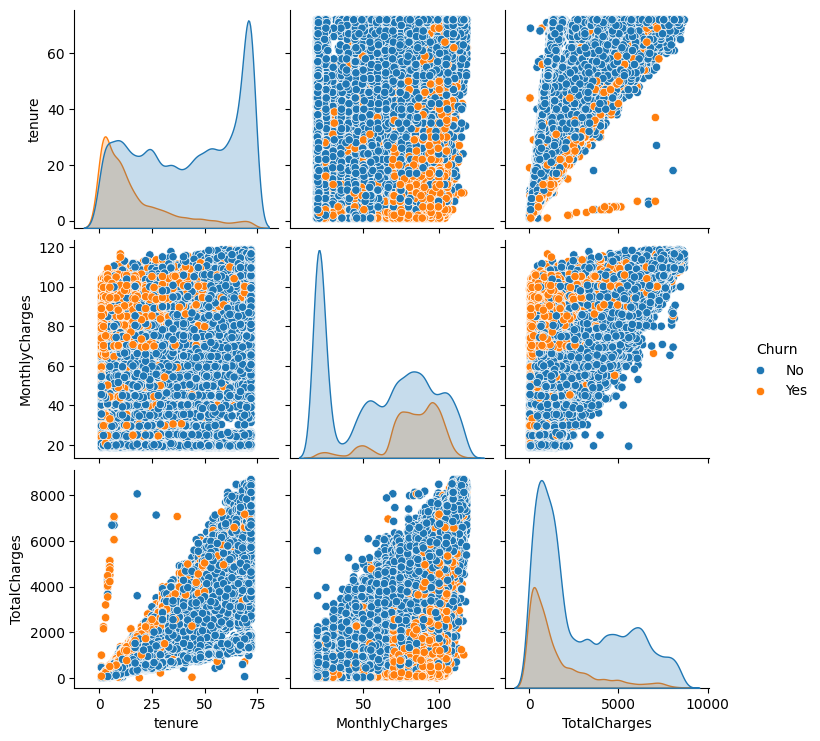

In [168]:
plt.figure(figsize = (16,12))
sns.pairplot(df.sample(frac=0.1)[numerical_columns+ target_column], hue="Churn")

- For "monthlycharge" and "totalcharges" there is significance difference in mean and median, that means these 2 are skewed.
- All 3 numerical columns contains significant number of outliers for Churned customers. there is no outliers for not churned.
- As tenure increases churn rate decreases. same for "Total charges".
- not much relationships between the numeric columns

## Categorical Columns

In [169]:
categorical_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

### Distribution of Categorical columns

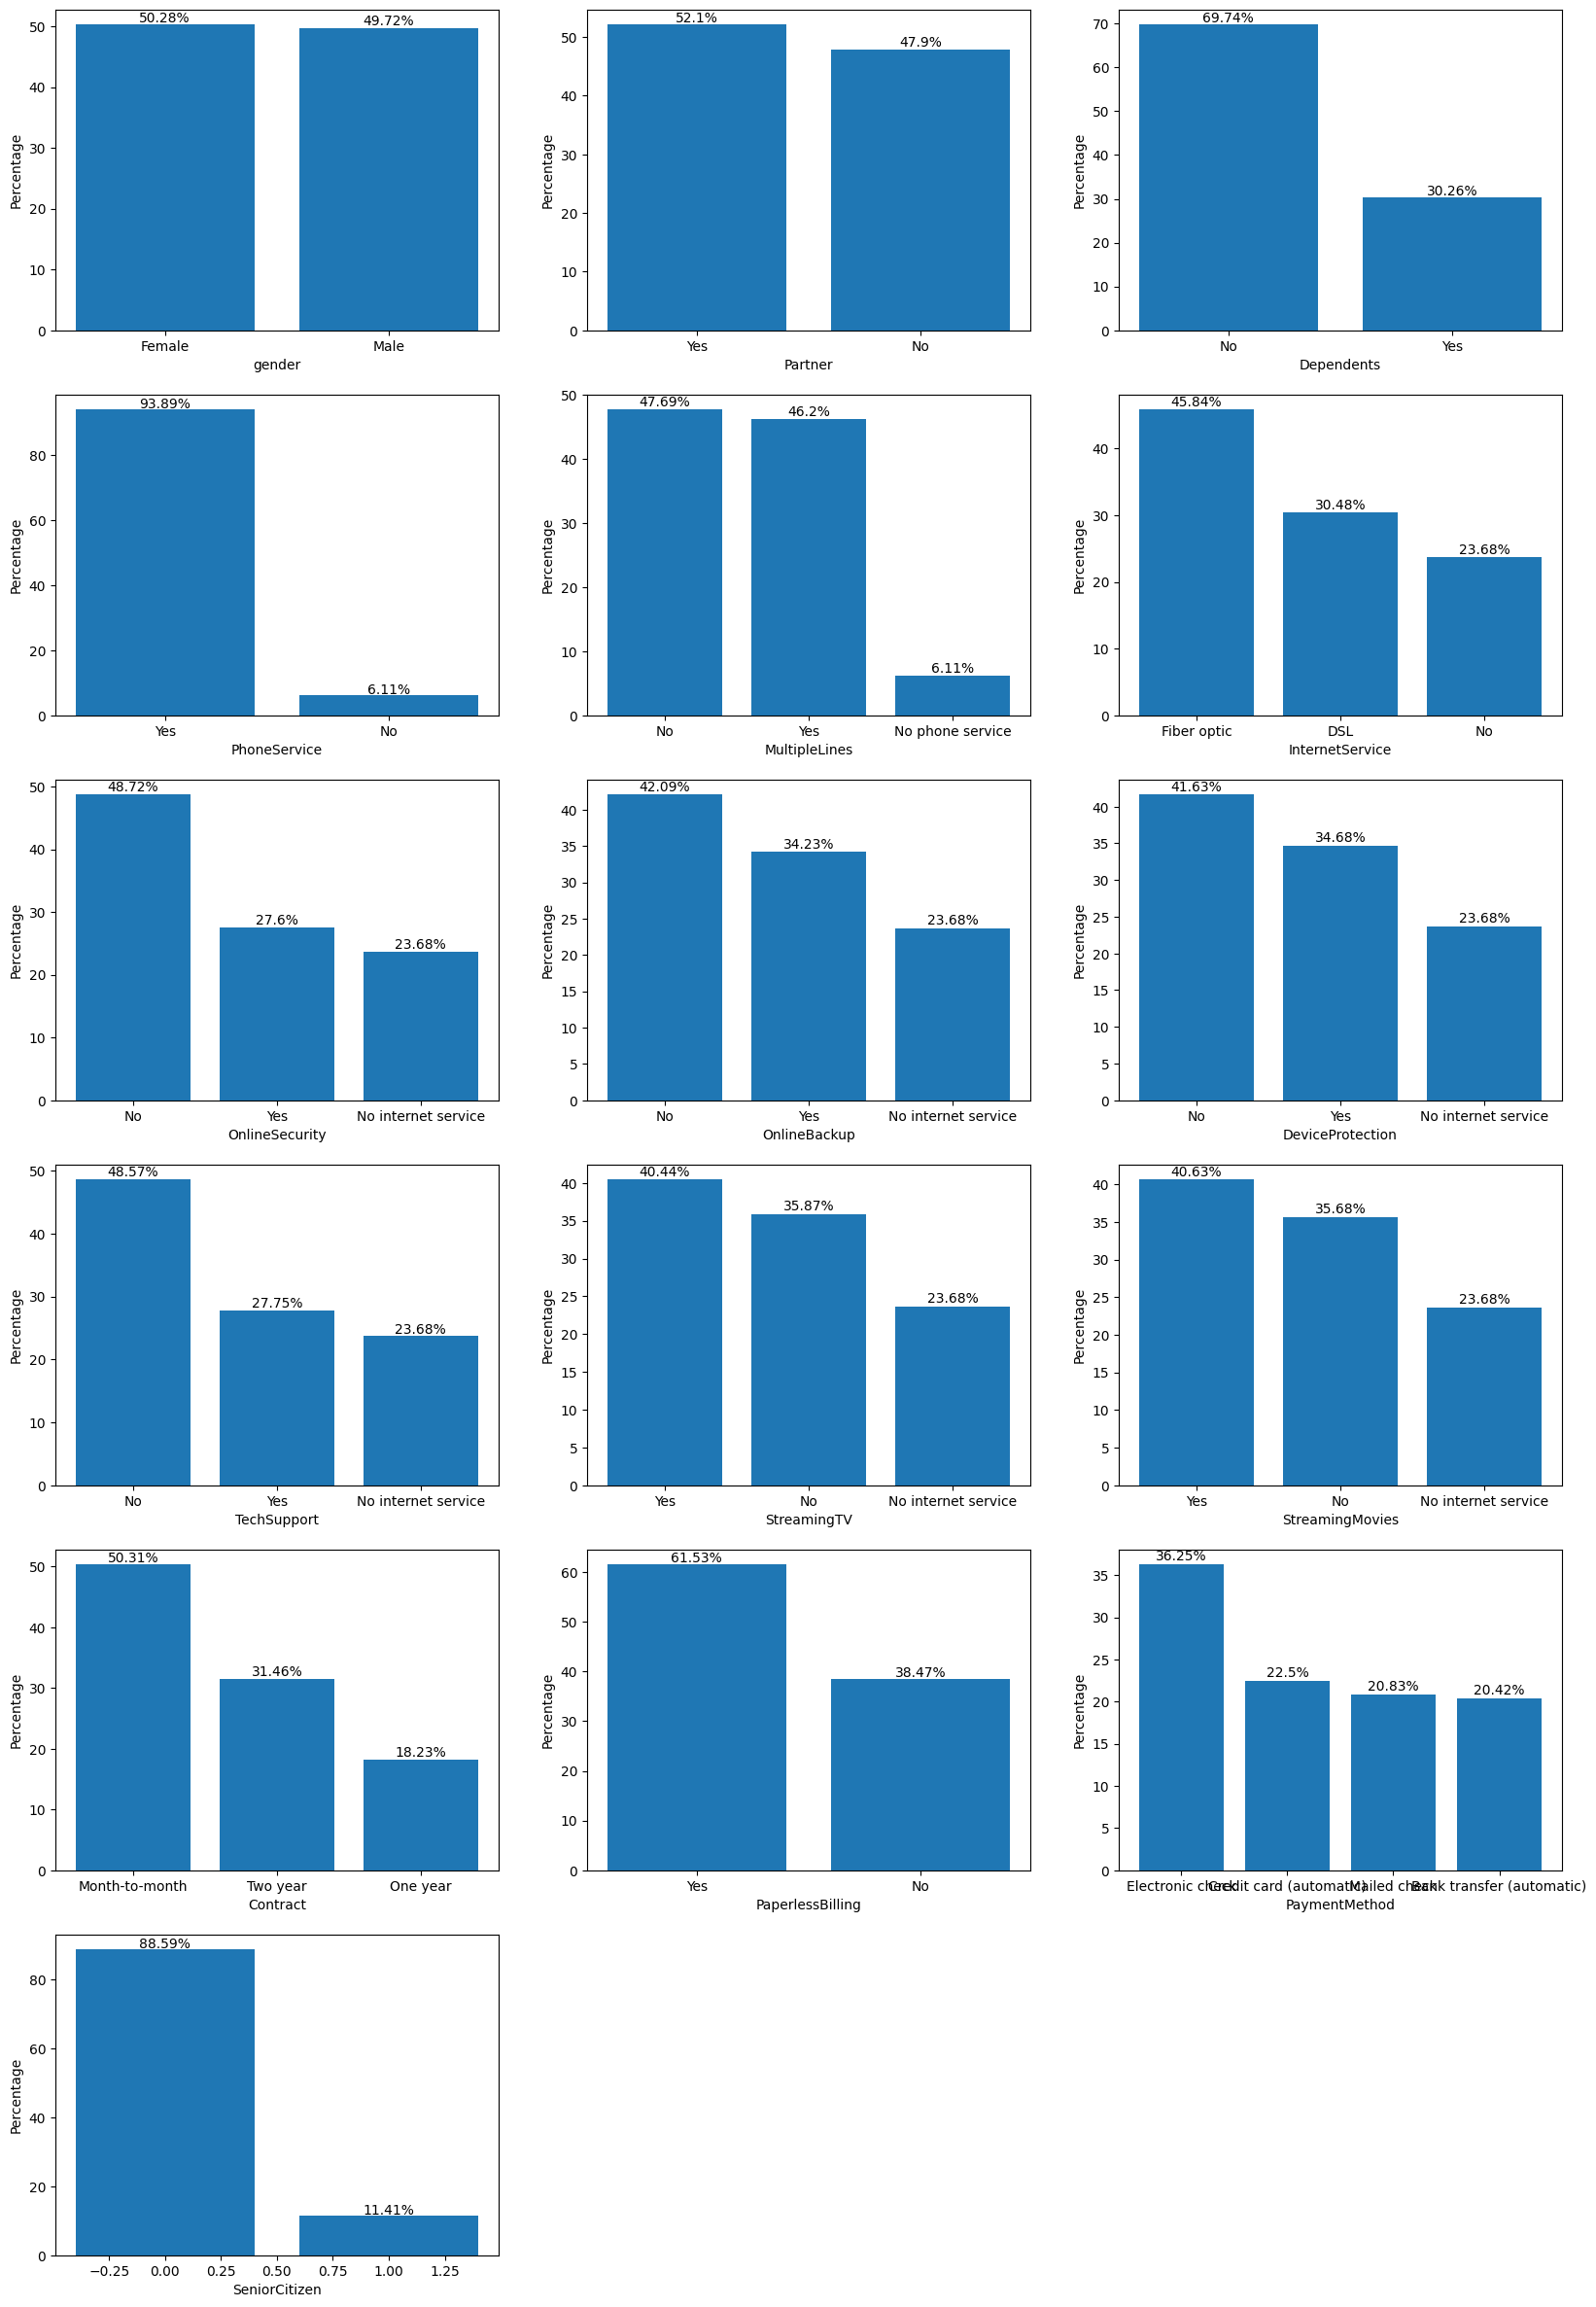

In [170]:
fig, axes = plt.subplots(6,3, figsize=(20,30))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    value_counts = (df[col].value_counts(normalize=True)*100).round(2)
    axes[i].bar(value_counts.index, value_counts.values)

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Percentage")

    for x, y in zip(value_counts.index, value_counts.values):
        axes[i].text(x, y+0.5, f"{y}%", ha="center")
    
    for j in range(len(categorical_columns), len(axes)):
        axes[j].set_visible(None)



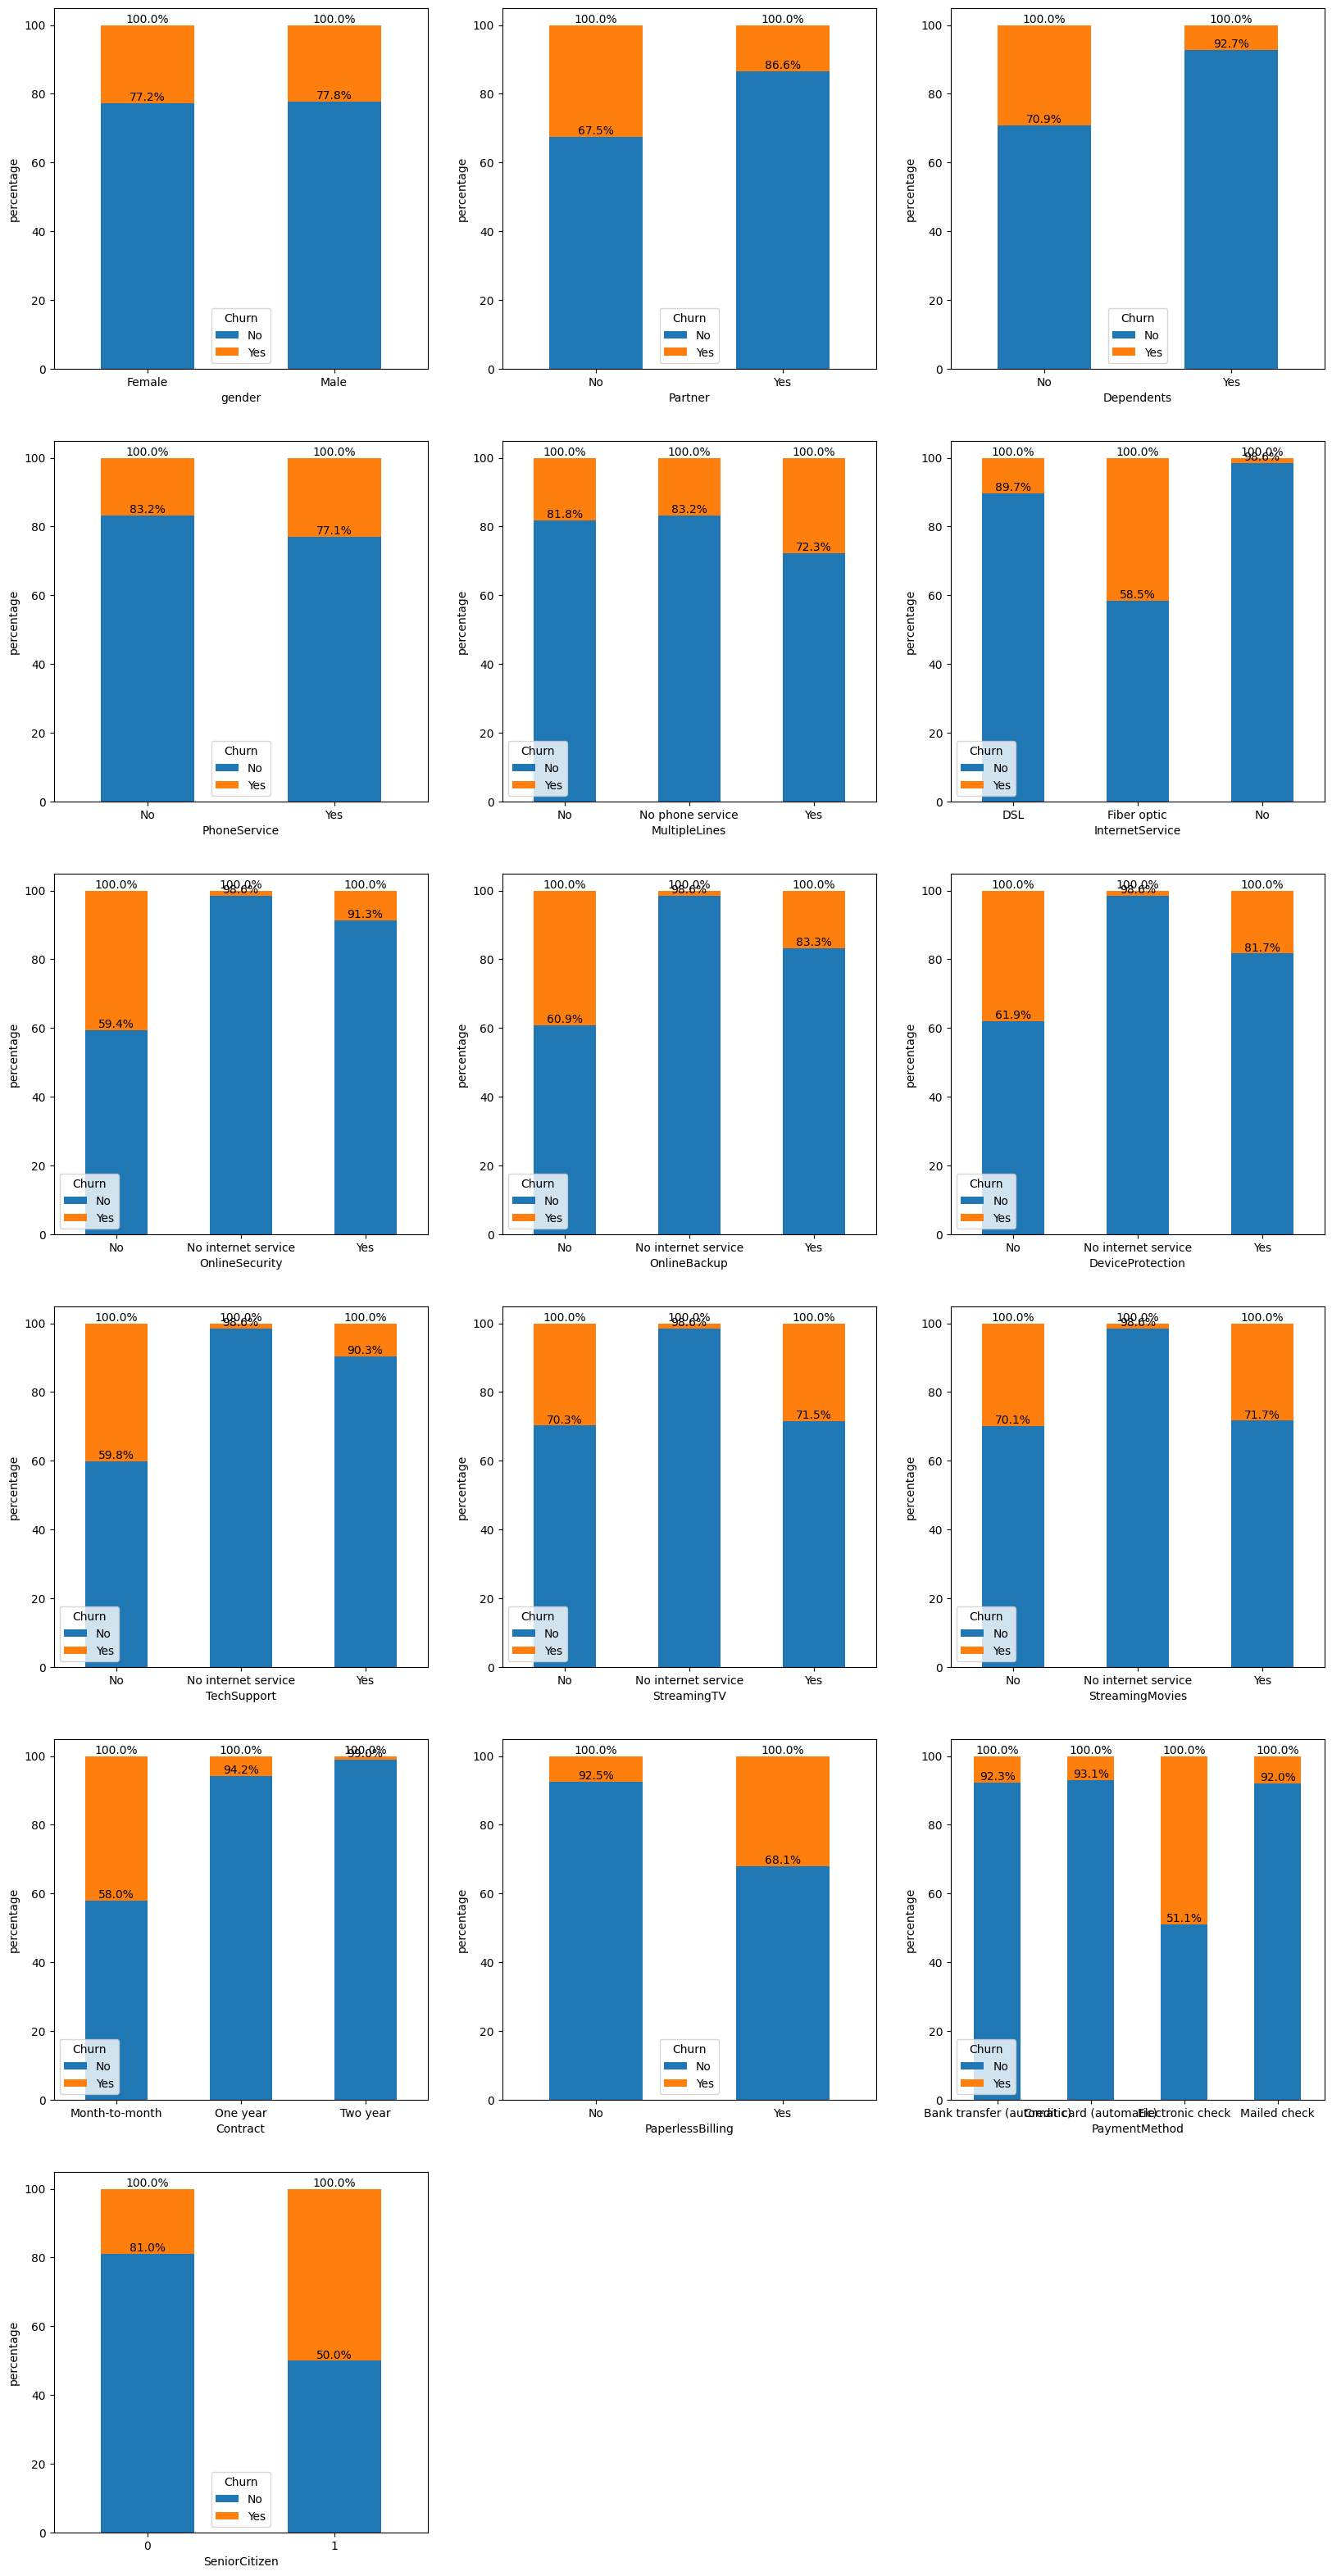

In [171]:
fig, axes = plt.subplots(6,3, figsize = (20,40))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    churn_distribution = (pd.crosstab(df[col], df["Churn"], normalize="index")*100).round(2)
    churn_distribution.plot(kind='bar', stacked=True, ax=axes[i])

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%')

    axes[i].tick_params(axis = 'x', rotation=0)
    axes[i].set_ylabel("percentage")

for j in range(len(categorical_columns), len(axes)):
    axes[j].set_visible(None)

### Looks Churn rate does not depend on gender, churn rate depends on all other categorical columns

In [172]:
df["MultipleLines"].value_counts()

MultipleLines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64

In [173]:
X = df.drop(["id", "Churn"], axis=1)
y = df["Churn"]

In [174]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45


In [175]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=9)

In [176]:
X_test.shape

(118839, 19)

In [177]:
categorical_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

In [178]:
#categorical_columns = categorical_columns.remove("gender")

In [179]:
from catboost import CatBoostClassifier

cb = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, random_seed=42)
cb.fit(X_train, y_train, cat_features=categorical_columns, eval_set=(X_test, y_test), early_stopping_rounds=50)

#print(f"catboost test AUC: {roc_auc_score(y_test, cb.predict(X_test))}")

0:	learn: 0.6437421	test: 0.6435456	best: 0.6435456 (0)	total: 170ms	remaining: 1m 24s
1:	learn: 0.6032461	test: 0.6029103	best: 0.6029103 (1)	total: 319ms	remaining: 1m 19s
2:	learn: 0.5666533	test: 0.5662665	best: 0.5662665 (2)	total: 468ms	remaining: 1m 17s
3:	learn: 0.5367406	test: 0.5362812	best: 0.5362812 (3)	total: 594ms	remaining: 1m 13s
4:	learn: 0.5075441	test: 0.5071206	best: 0.5071206 (4)	total: 746ms	remaining: 1m 13s
5:	learn: 0.4833440	test: 0.4829070	best: 0.4829070 (5)	total: 856ms	remaining: 1m 10s
6:	learn: 0.4619721	test: 0.4615543	best: 0.4615543 (6)	total: 973ms	remaining: 1m 8s
7:	learn: 0.4443353	test: 0.4439381	best: 0.4439381 (7)	total: 1.07s	remaining: 1m 6s
8:	learn: 0.4290031	test: 0.4286380	best: 0.4286380 (8)	total: 1.19s	remaining: 1m 4s
9:	learn: 0.4160914	test: 0.4157373	best: 0.4157373 (9)	total: 1.3s	remaining: 1m 3s
10:	learn: 0.4054732	test: 0.4051522	best: 0.4051522 (10)	total: 1.39s	remaining: 1m 1s
11:	learn: 0.3955734	test: 0.3952743	best: 0.39

CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, random_seed=42)

In [180]:
print(f"catboost test AUC: {roc_auc_score(y_test, cb.predict_proba(X_test)[:,1])}")
print(f"catboost train AUC: {roc_auc_score(y_train, cb.predict_proba(X_train)[:,1])}")

catboost test AUC: 0.915250179156573
catboost train AUC: 0.916637935339609


In [181]:
test_data = pd.read_csv("test.csv")
test_data.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [182]:
test_data_cleaned= test_data.drop(["id"], axis=1)

In [183]:
y_test_data_pred_proba = cb.predict_proba(test_data_cleaned)[:,1]
y_test_data_pred_proba

array([0.06649788, 0.00169919, 0.102323  , ..., 0.2941743 , 0.00335181,
       0.40765337], shape=(254655,))

In [184]:
#output = np.column_stack([test_data["id"], y_test_data_pred_proba])
output_df = pd.DataFrame({"id": test_data["id"], "Churn":y_test_data_pred_proba})
output_df

,id,Churn
0,594194,0.066498
1,594195,0.001699
2,594196,0.102323
3,594197,0.002285
4,594198,0.494896
...,...,...
254650,848844,0.001437
254651,848845,0.809876
254652,848846,0.294174
254653,848847,0.003352


In [185]:
output_df.to_csv("submission.csv", index=False)